In [12]:
import sqlalchemy as sal
import pandas as pd
import matplotlib.pyplot as plt

# connect to sql server

server = 'LAPTOP-91GGJ4MU'
database = 'BANKING'
engine=sal.create_engine(f"mssql+pyodbc://@{server}/{database}?driver=ODBC+Driver+17+for+SQL+Server")
conn=engine.connect()

In [13]:
# Loading data

df = pd.read_sql("SELECT * FROM dbo.financial_loan", conn)

In [ ]:
df.info()
df.isnull().sum()

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.dropna(axis=0,inplace=True)

In [19]:
# Convert date feilds

df['issue_date'] = pd.to_datetime(df['issue_date'], errors='coerce')
df['last_credit_pull_date'] = pd.to_datetime(df['last_credit_pull_date'], errors='coerce').dt.date
df['last_payment_date'] = pd.to_datetime(df['last_payment_date'], errors='coerce').dt.date
df['next_payment_date'] = pd.to_datetime(df['next_payment_date'], errors='coerce').dt.date


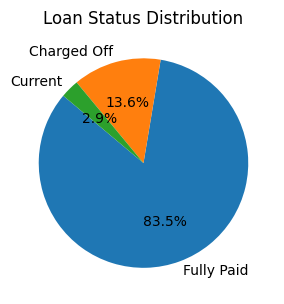

In [15]:
# Loan Distribution

value_counts = df['loan_status'].value_counts()

plt.figure(figsize=(3, 6))
plt.pie(
    value_counts,
    labels=value_counts.index,
    autopct='%1.1f%%',
    startangle=140)
plt.title('Loan Status Distribution')
plt.tight_layout()
plt.show()

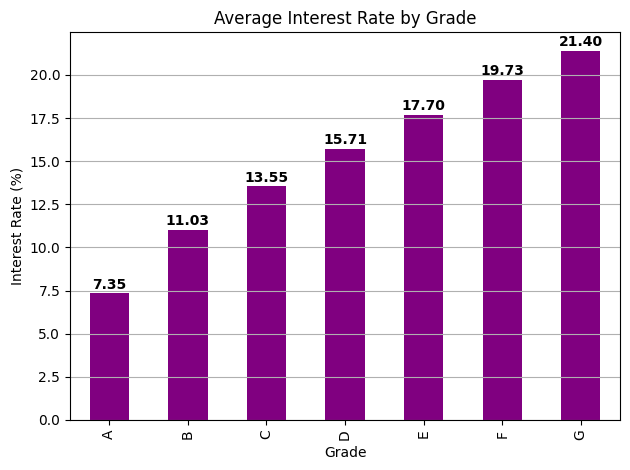

In [16]:
#Average Interest Rate by grade

avg_rates = df.groupby('grade')['interest_rate'].mean().sort_index()
ax = avg_rates.plot(kind='bar', color='purple')

# Annotate each bar
for i, val in enumerate(avg_rates):
    ax.text(i, val + 0.1, f"{val:.2f}", ha='center', va='bottom', fontweight='bold')

plt.title('Average Interest Rate by Grade')
plt.xlabel('Grade')
plt.ylabel('Interest Rate (%)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [23]:
df['month_name'] = df['issue_date'].dt.month_name()
df['month_number']=df['issue_date'].dt.month

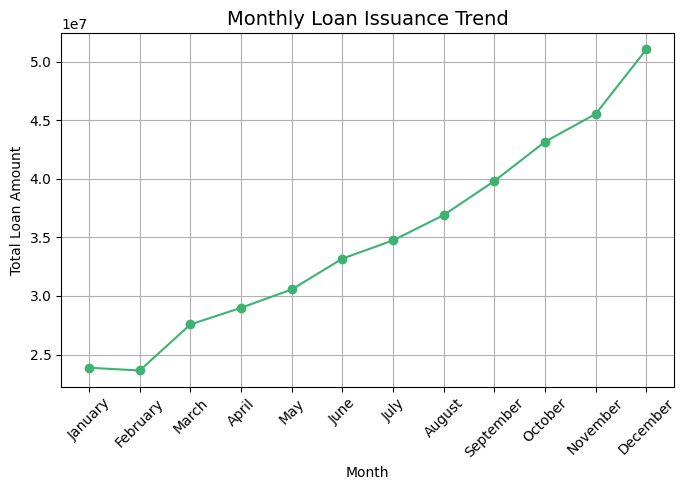

In [29]:
# Monthly Loan Amount Trend (Seasonal trends / loan volume growth)

monthly_loan=df.groupby(['month_name','month_number'])['loan_amount'].sum().reset_index()
monthly_loan = monthly_loan.sort_values('month_number')

plt.figure(figsize=(7, 5))
plt.plot(monthly_loan['month_name'], monthly_loan['loan_amount'], marker='o', color='mediumseagreen')
plt.title('Monthly Loan Issuance Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Loan Amount')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [31]:
df.to_sql('financial_loan', con=engine, schema='dbo', if_exists='replace', index=False)

29